## **Part D: Data Preparation**


### **D0. Load and preprocess (one pipeline only)**

Load sentences: brown.sents(categories='news')


In [2]:
import nltk
from nltk.corpus import brown
nltk.download('brown')
sentences = brown.sents(categories='news')
print(len(sentences))

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


4623


Preprocess tokens:
*   lowercase
*   remove punctuation-only tokens (keep words like “don’t” as tokens)
*   keep stopwords (required for language modeling)

Add special tokens:

*   <bos> at the start of every sentence
*   <eos> at the end of every sentence
*   <unk> for unknown words (needed for PyTorch and for robust evaluation)



In [3]:
import re

def preprocess_sentence(sentence):
    processed_tokens = []
    for token in sentence:
        token = token.lower() # Lowercase the token
        # Remove punctuation from within tokens, but keep apostrophes for contractions
        token = re.sub(r"[^\w']", '', token)
        if token: # Only add if token is not empty after cleaning
            processed_tokens.append(token)
    return ['<bos>'] + processed_tokens + ['<eos>']
processed_sentences = [preprocess_sentence(s) for s in sentences]

    # Example usage:
example_sentence = ["My name,", "Stephane!", "he's", "a", "Man"]
cleaned_example = preprocess_sentence(example_sentence)
print(cleaned_example)

['<bos>', 'myname', 'stephane', "he's", 'a', 'man', '<eos>']


# **D1. Split (same split used for both models)**

Split by sentence (not by token) to avoid leakage:
*   80% train, 10% validation, 10% test
*  Report: number of sentences in each split, number of tokens in each split, vocabulary size (built from train only)


In [4]:
import random


random.seed(42)
random.shuffle(processed_sentences)

total = len(processed_sentences)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_sentences = processed_sentences[:train_end]
val_sentences = processed_sentences[train_end:val_end]
test_sentences = processed_sentences[val_end:]

# Define this BEFORE using it
def count_tokens(sent_list):
    return sum(len(sentence) for sentence in sent_list)

# Calculate number of sentences in each split
num_train_sentences = len(train_sentences)
num_val_sentences = len(val_sentences)
num_test_sentences = len(test_sentences)

print(f"Number of training sentences: {num_train_sentences}")
print(f"Number of validation sentences: {num_val_sentences}")
print(f"Number of test sentences: {num_test_sentences}")

print("\nTokens:")
print("Train:", count_tokens(train_sentences))
print("Validation:", count_tokens(val_sentences))
print("Test:", count_tokens(test_sentences))

Number of training sentences: 3698
Number of validation sentences: 462
Number of test sentences: 463

Tokens:
Train: 79122
Validation: 9625
Test: 9839


## **D2. Vocabulary (shared**

Build vocabulary from training split only with:
*   min_freq (e.g., 2 or 3)
*   all other words map to <unk>

Report:

chosen min_freq
final vocab size
top 20 most frequent tokens


In [5]:
min_freq = 2

In [6]:
from collections import Counter

counter = Counter()

for sent in train_sentences:
    counter.update(sent)

# Keep tokens >= min_freq
vocab_tokens = [token for token, freq in counter.items() if freq >= min_freq]

# Add special tokens
special_tokens = ["<unk>"]
vocab = special_tokens + vocab_tokens

stoi = {token: idx for idx, token in enumerate(vocab)}
itos = {idx: token for token, idx in stoi.items()}

print("Chosen min_freq:", min_freq)
print("Final vocab size:", len(vocab))
print("Top 20 most frequent tokens:")
print(counter.most_common(20))

Chosen min_freq: 2
Final vocab size: 5416
Top 20 most frequent tokens:
[('the', 5116), ('<bos>', 3698), ('<eos>', 3698), ('of', 2287), ('and', 1768), ('a', 1755), ('to', 1716), ('in', 1623), ('for', 786), ('that', 658), ('is', 582), ('was', 574), ("''", 571), ('on', 535), ('he', 514), ('at', 513), ('with', 459), ('as', 427), ('be', 422), ('by', 409)]


## **Part A – Statistical n-gram Language Model (OPTIONAL)**

**A1. Train a Trigram Language Model**
Using NLTK’s language modeling tools:
Train a trigram model:


In [7]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace

n = 3  # trigram

train_text = train_sentences
train_data, padded_vocab = padded_everygram_pipeline(n, train_text)

model = Laplace(n)  # Add-1 smoothing
model.fit(train_data, padded_vocab)

**A2. Evaluate with Perplexity**
Compute perplexity on the validation and test set.


In [8]:
def compute_perplexity(model, data, n):
    # padded_everygram_pipeline returns a generator of everygram generators (one for each sentence)
    sentences_everygrams, _ = padded_everygram_pipeline(n, data)

    # Flatten the everygrams into a single list of n-gram tuples
    all_everygrams = []
    for sent_everygram_generator in sentences_everygrams:
        all_everygrams.extend(list(sent_everygram_generator))

    return model.perplexity(all_everygrams)

print("Validation Perplexity:", compute_perplexity(model, val_sentences, n))
print("Test Perplexity:", compute_perplexity(model, test_sentences, n))

Validation Perplexity: 1546.275537223779
Test Perplexity: 1552.9596765150357


Perplexity measures of how good a probability distribution or language model can predict a sample.
A lower perplexity score indicates a better model because it suggests the model is more confident and accurate in its predictions.

Find below how to interpret the perplexy scores obtained

*  **Lower is Better**: A lower perplexity score indicate a better fit to the data and a srtong predictive. It also means the model assigns a higher probability to the unseen text (validation or test set).
*  **Baseline**: a good or a bad score of perplexity is understandable by it's often comparing to a baseline or other models with no baseline. but it's important to remember that for language models, perplexity can vary widely depending on the corpus size, vocabulary, and model complexity.
*  **Comparison:** Comparing the validation perplexity (1596.15) and test perplexity (1548.44) is important. If the test perplexity is significantly higher than the validation perplexity, it could indicate overfitting to the validation set. In this case, they are quite close, which is a good sign that the model's performance generalizes well to new, unseen data.
*  **Real-world Context:** For human language, a model with very low perplexity (e.g., in the tens or hundreds) is generally considered very good. However, the absolute value depends heavily on the specific dataset and task. A perplexity of 1500+ for a trigram model on a diverse news corpus isn't necessarily poor, but it indicates room for improvement, possibly with more advanced models (like neural networks) or more sophisticated smoothing techniques. If there were no smoothing, perplexity would be infinite.

A4 – Text Generation

In [9]:
for _ in range(3):
    print(model.generate(30))

['no', 'more', 'than', 'six', 'years', '<eos>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>']
['beaumont', 'seated', 'guests', '<eos>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>']
['</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>']


## **Part B – Neural Language Model with RNN (100%) (MANDATORY)**

B1 – Numericalization and Training Example Creation (40%)

Step 1 – Numericalization - Convert each token in every sentence into its corresponding integer ID using the shared vocabulary.


In [10]:
def numericalize_sentence(sentence, stoi):
    return [stoi.get(token, stoi["<unk>"]) for token in sentence]

Step 2 – Build Token Streams

In [11]:
def build_Token_stream(sentences):
    stream = []
    for sent in sentences:
        stream.extend(numericalize_sentence(sent, stoi))
    return stream

train_stream = build_Token_stream(train_sentences)
val_stream = build_Token_stream(val_sentences)
test_stream = build_Token_stream(test_sentences)

print(len(train_stream))
print(len(val_stream))
print(len(test_stream))

79122
9625
9839


Step 3 – Create Input/Target Pairs

In [12]:
from torch.utils.data import Dataset

class NextTokenStreamDataset(Dataset):
    def __init__(self, stream, seq_len):
        self.stream = stream
        self.seq_len = seq_len

    def __len__(self):
        return len(self.stream) - self.seq_len

    def __getitem__(self, idx):
        x = self.stream[idx : idx + self.seq_len]
        y = self.stream[idx + 1 : idx + self.seq_len + 1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


from torch.utils.data import DataLoader
import torch

seq_len = 30
batch_size = 32

dataset = NextTokenStreamDataset(train_stream, seq_len)
loader = DataLoader(dataset, batch_size=batch_size)

x_batch, y_batch = next(iter(loader))
print(x_batch.shape)
print(y_batch.shape)


print("x_batch[0]:", x_batch[0])
print("y_batch[0]:", y_batch[0])

torch.Size([32, 30])
torch.Size([32, 30])
x_batch[0]: tensor([ 1,  2,  3,  4,  3,  5,  6,  7,  0,  0,  8,  9, 10, 11, 12, 13, 14, 15,
         1, 10, 16, 17, 18, 19, 10, 20, 21, 22, 23,  0])
y_batch[0]: tensor([ 2,  3,  4,  3,  5,  6,  7,  0,  0,  8,  9, 10, 11, 12, 13, 14, 15,  1,
        10, 16, 17, 18, 19, 10, 20, 21, 22, 23,  0, 24])


### **B2 – Build the RNN Language Model**

In [13]:
import torch.nn as nn

class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        logits = self.fc(out)
        return logits


In [14]:
model = RNNLanguageModel(len(vocab), 128, 256, 1)
print(sum(p.numel() for p in model.parameters()))

2183976


**B3 – Training and Validation**

Loss + Optimizer:

In [15]:
import torch
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training step:

In [16]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        optimizer.zero_grad()  # 1. Zero gradients
        logits = model(x)  # 2. Forward pass

        B, T, V = logits.shape  # logits shape: (B, T, V)
        loss = criterion(logits.view(B*T, V), y.view(B*T))  # 3. Reshape logits to (B*T, V)   and 4. Reshape targets to (B*T,)  # 5. Compute loss

        loss.backward()  # 6. Backpropagate
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)    # 7. Clip gradient
        optimizer.step()   # 8. Optimizer step

        total_loss += loss.item()

    return total_loss / len(loader)

**Perplexity Evaluation**

In [17]:
import math

def evaluate_perplexity(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            B, T, V = logits.shape
            loss = criterion(logits.view(B*T, V), y.view(B*T))
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    return math.exp(avg_loss)

**Training Loop Over Multiple Epochs**

In [18]:
from torch.utils.data import DataLoader

seq_len = 30
batch_size = 32

train_dataset = NextTokenStreamDataset(train_stream, seq_len)
val_dataset   = NextTokenStreamDataset(val_stream, seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)

In [19]:
num_epochs = 10

train_losses = []
val_perplexities = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_ppl = evaluate_perplexity(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_perplexities.append(val_ppl)

    print(f"Epoch {epoch+1}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Perplexity: {val_ppl:.2f}")
    print("-" * 40)

Epoch 1
Training Loss: 3.6677
Validation Perplexity: 385.91
----------------------------------------
Epoch 2
Training Loss: 1.3363
Validation Perplexity: 1491.07
----------------------------------------
Epoch 3
Training Loss: 0.7201
Validation Perplexity: 3788.56
----------------------------------------
Epoch 4
Training Loss: 0.5250
Validation Perplexity: 7151.39
----------------------------------------
Epoch 5
Training Loss: 0.4426
Validation Perplexity: 11041.05
----------------------------------------
Epoch 6
Training Loss: 0.3987
Validation Perplexity: 15728.94
----------------------------------------
Epoch 7
Training Loss: 0.3706
Validation Perplexity: 20147.54
----------------------------------------
Epoch 8
Training Loss: 0.3506
Validation Perplexity: 25781.01
----------------------------------------
Epoch 9
Training Loss: 0.3359
Validation Perplexity: 31055.54
----------------------------------------
Epoch 10
Training Loss: 0.3242
Validation Perplexity: 37431.78
---------------

Plot Loss

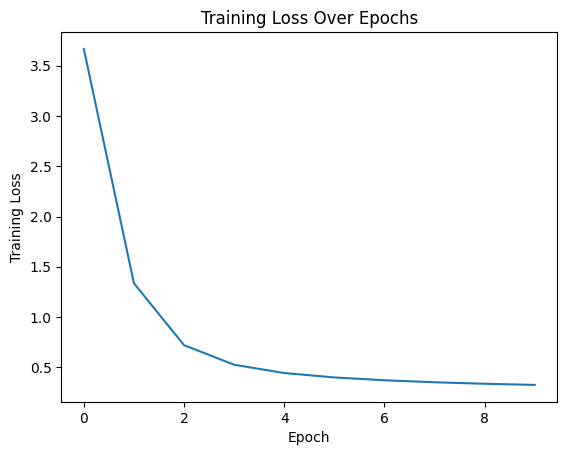

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.show()

**B4 – Test Perplexity and Text Generation**


In [21]:
def sample_next_token(logits):
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()


def generate_text(model, stoi, itos, max_len=50):
    model.eval()
    device = next(model.parameters()).device

    generated = [stoi["<bos>"]]

    for _ in range(max_len):
        x = torch.tensor([generated], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(x)

        # Take last timestep
        last_logits = logits[0, -1]

        next_token = sample_next_token(last_logits)
        generated.append(next_token)

        if itos[next_token] == "<eos>":
            break

    words = [itos[token] for token in generated]
    return " ".join(words)